In [1]:
import qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino

# Visualize both histograms
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt



In [2]:
MAX_HOPS = 2
MIN_HOPS = 1
NUM_SHOTS = 100

In [3]:
# The nodes of the network
node_names = [0, 1, 2, 3, 4, 5]

# =============================================================================
# FIXED PHYSICAL QUBIT MAPPING
# =============================================================================
# Each network node is assigned to specific physical qubits on FakeFez.
# This ensures consistent noise characteristics across all runs:
# - Node X always uses the same physical qubits regardless of circuit structure
# - When Node X is absent from a circuit, its physical qubits are NOT used by other nodes
#
# Each node needs 9 qubits for the [[5,1,3]] code:
#   - Qubits 0-4: Data + Encoding qubits (the 5 code qubits)
#   - Qubits 5-8: Ancilla qubits for syndrome measurement

NODE_PHYSICAL_QUBITS = {
    0: list(range(0, 9)),      # Node 0 → physical qubits 0-8
    1: list(range(9, 18)),     # Node 1 → physical qubits 9-17
    2: list(range(18, 27)),    # Node 2 → physical qubits 18-26
    3: list(range(27, 36)),    # Node 3 → physical qubits 27-35
    4: list(range(36, 45)),    # Node 4 → physical qubits 36-44
    5: list(range(45, 54)),    # Node 5 → physical qubits 45-53
}

# Physical qubits for path/channel registers (1 qubit per edge for swapping)
PATH_PHYSICAL_QUBITS = {
    (0, 1): [54,55],
    (0, 3): [56],
    (1, 2): [57,58],
    (1, 4): [59],
    (2, 5): [60],
    (3, 4): [61,62],
    (4, 5): [63,64],
}

# PATH_PHYSICAL_QUBITS = {
#     (0, 1): [54],
#     (0, 3): [55],
#     (1, 2): [56],
#     (1, 4): [57],
#     (2, 5): [58],
#     (3, 4): [59],
#     (4, 5): [60],
# }

# Total physical qubits needed: 54 (nodes) + 7 (paths) = 61
TOTAL_QUBITS = len(NODE_PHYSICAL_QUBITS)*9 + sum(len(q) for q in PATH_PHYSICAL_QUBITS.values())

print("Node to Physical Qubit Mapping:")
for node, qubits in NODE_PHYSICAL_QUBITS.items():
    print(f"  Node {node}: physical qubits {qubits[0]}-{qubits[-1]}")
print(f"\nPath Register Physical Qubits: {PATH_PHYSICAL_QUBITS}")
print(f"Total physical qubits used: {TOTAL_QUBITS}")

Node to Physical Qubit Mapping:
  Node 0: physical qubits 0-8
  Node 1: physical qubits 9-17
  Node 2: physical qubits 18-26
  Node 3: physical qubits 27-35
  Node 4: physical qubits 36-44
  Node 5: physical qubits 45-53

Path Register Physical Qubits: {(0, 1): [54, 55], (0, 3): [56], (1, 2): [57, 58], (1, 4): [59], (2, 5): [60], (3, 4): [61, 62], (4, 5): [63, 64]}
Total physical qubits used: 65


In [4]:
# =============================================================================
# NOISE MODEL SETUP (Decoupled from Coupling Constraints)
# =============================================================================
# We extract ONLY the noise model from FakeFez (T1, T2, gate errors, readout errors)
# but do NOT enforce its coupling map. This means:
#   - We get realistic per-qubit noise characteristics
#   - We can connect any qubits we want (no topology constraints)
#   - Physical qubit indices determine which noise profile is applied

fake_backend = FakeFez()
# fake_backend = FakeTorino()
network_channel_noise = NoiseModel.from_backend(fake_backend)

# CRITICAL: FakeFez basis gates - circuits MUST be decomposed to these for noise to apply
# The noise model only has error definitions for these gates!
FEZ_BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Noise Model extracted from {fake_backend}")
print(f"  Backend qubits: {fake_backend.num_qubits}")
print(f"  Noise model basis gates: {network_channel_noise.basis_gates}")
print(f"  Gates with noise defined: {network_channel_noise.noise_instructions}")
print(f"\nIMPORTANT: Circuits must be transpiled to basis gates: {FEZ_BASIS_GATES}")
print(f"  SWAP gates will be decomposed to CZ + SX gates for proper noise application")

Noise Model extracted from <qiskit_ibm_runtime.fake_provider.backends.fez.fake_fez.FakeFez object at 0x1170baf90>
  Backend qubits: 156
  Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gates with noise defined: ['cz', 'id', 'measure', 'reset', 'sx', 'x']

IMPORTANT: Circuits must be transpiled to basis gates: ['cz', 'id', 'rz', 'sx', 'x']
  SWAP gates will be decomposed to CZ + SX gates for proper noise application


In [5]:
# Verify the physical qubit assignments
print("Physical Qubit Assignments Summary:")
print("-" * 50)
for node in node_names:
    qubits = NODE_PHYSICAL_QUBITS[node]
    print(f"Node {node}: qubits {qubits[0]:2d}-{qubits[-1]:2d} (data={qubits[4]}, ancillas={qubits[5:9]})")

Physical Qubit Assignments Summary:
--------------------------------------------------
Node 0: qubits  0- 8 (data=4, ancillas=[5, 6, 7, 8])
Node 1: qubits  9-17 (data=13, ancillas=[14, 15, 16, 17])
Node 2: qubits 18-26 (data=22, ancillas=[23, 24, 25, 26])
Node 3: qubits 27-35 (data=31, ancillas=[32, 33, 34, 35])
Node 4: qubits 36-44 (data=40, ancillas=[41, 42, 43, 44])
Node 5: qubits 45-53 (data=49, ancillas=[50, 51, 52, 53])


In [6]:
# Verify path register assignments
print("\nPath Register Assignments:")
print("-" * 50)
for edge, qubits in PATH_PHYSICAL_QUBITS.items():
    print(f"Edge {edge}: path qubit(s) = {qubits}")


Path Register Assignments:
--------------------------------------------------
Edge (0, 1): path qubit(s) = [54, 55]
Edge (0, 3): path qubit(s) = [56]
Edge (1, 2): path qubit(s) = [57, 58]
Edge (1, 4): path qubit(s) = [59]
Edge (2, 5): path qubit(s) = [60]
Edge (3, 4): path qubit(s) = [61, 62]
Edge (4, 5): path qubit(s) = [63, 64]


{(0, 1): 1, (1, 2): 1, (0, 3): 1, (1, 4): 1, (2, 5): 1, (3, 4): 1, (4, 5): 1}


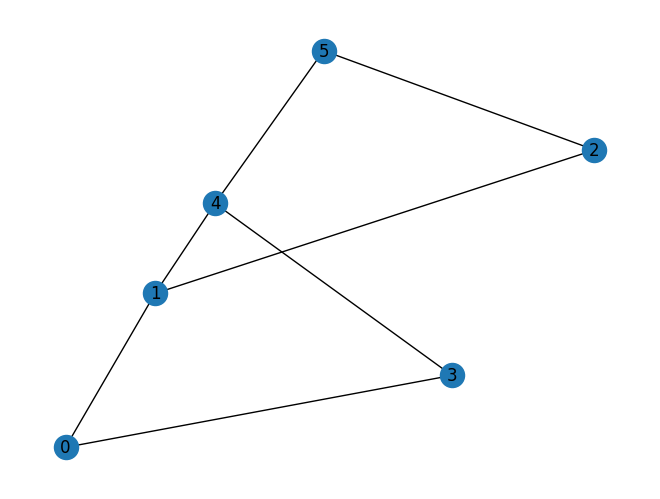

In [7]:
import networkx as nx

network_graph = nx.Graph()
network_graph.add_nodes_from(node_names)
network_graph.add_edges_from([(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5)])
nx.draw(network_graph, with_labels=True)

swaps_per_edge = {
    (0, 1): 1,
    (1, 2): 1,
    (0, 3): 1,
    (1, 4): 1,
    (2, 5): 1,
    (3, 4): 1,
    (4, 5): 1
}
print(swaps_per_edge)

In [8]:
# Multi-hop paths:
from itertools import combinations
ALL_HOP_PATHS = []
for pairs in combinations(node_names, 2):
    multi_hop_paths = nx.all_simple_paths(network_graph, source=pairs[0], target=pairs[1], cutoff=MAX_HOPS)
    ALL_HOP_PATHS.extend([x for x in multi_hop_paths if len(x) > MIN_HOPS])

print("All multi-hop paths:", ALL_HOP_PATHS)

All multi-hop paths: [[0, 1], [0, 1, 2], [0, 3], [0, 1, 4], [0, 3, 4], [1, 2], [1, 0, 3], [1, 4, 3], [1, 4], [1, 2, 5], [1, 4, 5], [2, 1, 4], [2, 5, 4], [2, 5], [3, 4], [3, 4, 5], [4, 5]]


In [9]:
# =============================================================================
# CIRCUIT BUILDING FUNCTIONS (Using Physical Qubits Directly)
# =============================================================================
# These functions build circuits using physical qubit indices from NODE_PHYSICAL_QUBITS.
# This ensures consistent qubit-to-noise mapping across all runs.

# Syndrome-to-correction lookup table for [[5,1,3]] code
# Stabilizers: g1=XZZXI, g2=IXZZX, g3=XIXZZ, g4=ZXIXZ
# Syndrome bits ordered [g1, g2, g3, g4] (ancilla indices 5,6,7,8)
# Correction tuple: (qubit_index, pauli_operator) or None for no error
SYNDROME_TO_CORRECTION = {
    0:  None,        # No error
    1:  (0, 'X'),    # X error on qubit 0  - syndrome 0001
    2:  (2, 'Z'),    # Z error on qubit 2  - syndrome 0010
    3:  (4, 'X'),    # X error on qubit 4  - syndrome 0011
    4:  (4, 'Z'),    # Z error on qubit 4  - syndrome 0100
    5:  (1, 'Z'),    # Z error on qubit 1  - syndrome 0101
    6:  (3, 'X'),    # X error on qubit 3  - syndrome 0110
    7:  (4, 'Y'),    # Y error on qubit 4  - syndrome 0111
    8:  (1, 'X'),    # X error on qubit 1  - syndrome 1000
    9:  (3, 'Z'),    # Z error on qubit 3  - syndrome 1001
    10: (0, 'Z'),    # Z error on qubit 0  - syndrome 1010
    11: (0, 'Y'),    # Y error on qubit 0  - syndrome 1011
    12: (2, 'X'),    # X error on qubit 2  - syndrome 1100
    13: (1, 'Y'),    # Y error on qubit 1  - syndrome 1101
    14: (2, 'Y'),    # Y error on qubit 2  - syndrome 1110
    15: (3, 'Y'),    # Y error on qubit 3  - syndrome 1111
}


def apply_encoding(qc, qubits):
    """
    Apply [[5,1,3]] encoding circuit.
    
    Args:
        qc: QuantumCircuit
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4] where q4 is the data qubit
    """
    qc.h(qubits[0])
    qc.z(qubits[0])
    qc.cz(qubits[0], qubits[4])
    qc.cx(qubits[0], qubits[4])

    qc.h(qubits[1])
    qc.cx(qubits[1], qubits[4])

    qc.h(qubits[2])
    qc.cx(qubits[2], qubits[4])
    qc.cz(qubits[2], qubits[1])
    qc.cz(qubits[2], qubits[0])

    qc.h(qubits[3])
    qc.z(qubits[3])
    qc.cz(qubits[3], qubits[4])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[2])
    qc.cz(qubits[3], qubits[0])


def apply_decoding(qc, qubits):
    """
    Apply [[5,1,3]] decoding circuit (inverse of encoding).
    After decoding, the logical qubit is on qubit[4] (the original data qubit).
    
    Args:
        qc: QuantumCircuit
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4]
    """
    # Reverse of encoding: apply gates in reverse order
    # Each gate is self-inverse (H†=H, Z†=Z, CZ†=CZ, CX†=CX)
    
    # Reverse of qubit 3 block
    qc.cz(qubits[3], qubits[0])
    qc.cz(qubits[3], qubits[2])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[4])
    qc.z(qubits[3])
    qc.h(qubits[3])

    # Reverse of qubit 2 block
    qc.cz(qubits[2], qubits[0])
    qc.cz(qubits[2], qubits[1])
    qc.cx(qubits[2], qubits[4])
    qc.h(qubits[2])

    # Reverse of qubit 1 block
    qc.cx(qubits[1], qubits[4])
    qc.h(qubits[1])

    # Reverse of qubit 0 block
    qc.cx(qubits[0], qubits[4])
    qc.cz(qubits[0], qubits[4])
    qc.z(qubits[0])
    qc.h(qubits[0])


def apply_coherent_correction(qc, data_qubits, ancilla_qubits):
    """
    Apply coherent error correction using ancilla qubits as controls.
    No measurement needed - uses ancilla states directly to control corrections.
    
    Args:
        qc: QuantumCircuit to add corrections to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3] for syndromes g1,g2,g3,g4
    """
    # Ancilla mapping: ancilla_qubits[0]=g1, [1]=g2, [2]=g3, [3]=g4
    # Syndrome integer: g1*8 + g2*4 + g3*2 + g4*1
    
    for syndrome_val, correction in SYNDROME_TO_CORRECTION.items():
        if correction is None:
            continue
        
        qubit_idx, pauli = correction
        target = data_qubits[qubit_idx]
        
        # Convert syndrome value to control pattern
        # syndrome_val in binary: bit3=g1, bit2=g2, bit1=g3, bit0=g4
        ctrl_pattern = [(syndrome_val >> (3-i)) & 1 for i in range(4)]
        
        # Build control list with proper polarities
        # For each ancilla: if pattern bit is 0, we need X gate to flip before and after (negative control)
        controls = []
        for i, bit in enumerate(ctrl_pattern):
            controls.append(ancilla_qubits[i])
        
        # Apply X gates to ancillas where we need negative control (bit=0)
        for i, bit in enumerate(ctrl_pattern):
            if bit == 0:
                qc.x(ancilla_qubits[i])
        
        # Apply the correction as multi-controlled gate
        if pauli == 'X':
            qc.mcx(controls, target)
        elif pauli == 'Z':
            # MCZ = H-MCX-H on target
            qc.h(target)
            qc.mcx(controls, target)
            qc.h(target)
        elif pauli == 'Y':
            # Y = iXZ, apply both
            qc.mcx(controls, target)
            qc.h(target)
            qc.mcx(controls, target)
            qc.h(target)
        
        # Undo the X gates on ancillas (restore their state)
        for i, bit in enumerate(ctrl_pattern):
            if bit == 0:
                qc.x(ancilla_qubits[i])


def build_source_correcting_circuit_physical(node, initial_state='0', decode_before_measure=True):
    """
    Build a single-hop syndrome circuit using physical qubit indices.
    
    Args:
        node: node ID (0-5)
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    # Get physical qubit indices for source and sink nodes
    node_qubits = NODE_PHYSICAL_QUBITS[node]  # 9 qubits
    
    # Create circuit with enough qubits
    qc = QuantumCircuit(TOTAL_QUBITS)

    # Add classical register based on measurement mode
    if decode_before_measure:
        logical_bits = ClassicalRegister(1, name='c_logical')
    else:
        logical_bits = ClassicalRegister(5, name='c_logical')
    qc.add_register(logical_bits)
    
    
    if initial_state == '1':
        qc.x(node_qubits[4])

    # Encoding using [[5,1,3]] code
    apply_encoding(qc, node_qubits[:5])
    
    qc.barrier(label='Encoding Complete')
    
    # Syndrome measurement at sink
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

    for idx, stabilizer in enumerate(stabilizers):
        ancilla_idx = idx + 5  # Ancillas are at indices 5-8
        qc.h(node_qubits[ancilla_idx])
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(node_qubits[ancilla_idx], node_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(node_qubits[ancilla_idx], node_qubits[qubit_idx])
        
        qc.h(node_qubits[ancilla_idx])

    # Apply coherent correction using ancillas as controls
    data_qubits = [node_qubits[i] for i in range(5)]
    ancilla_qubits = [node_qubits[i] for i in range(5, 9)]  # ancillas 5,6,7,8
    apply_coherent_correction(qc, data_qubits, ancilla_qubits)

    qc.barrier(label='Correction Applied')

    if decode_before_measure:
        # MODE 1: Decode then measure single qubit
        apply_decoding(qc, node_qubits[:5])
        qc.barrier(label='Decoding Complete')
        # Measure only the data qubit (index 4) which now holds the logical state
        qc.measure(node_qubits[4], logical_bits[0])
    else:
        # MODE 2: Measure all 5 qubits, compute parity in post-processing
        # Logical Z = Z0*Z1*Z2*Z3*Z4, so parity gives logical outcome
        for i in range(5):
            qc.measure(node_qubits[i], logical_bits[i])

    return qc

def compute_logical_success_rate_parity(counts, expected_logical_state='0'):
    """
    Compute logical success rate from 5-qubit measurement using parity.
    
    For [[5,1,3]] code, logical Z = Z0*Z1*Z2*Z3*Z4 (parity of all bits).
    - Even parity → Logical |0⟩
    - Odd parity  → Logical |1⟩
    
    Args:
        counts: Dictionary of {bitstring: count}
        expected_logical_state: '0' or '1'
    
    Returns:
        success_rate, correct_count, total_count
    """
    correct_count = 0
    total_count = 0
    
    expected_parity = int(expected_logical_state)
    
    for bitstring, count in counts.items():
        total_count += count
        # Compute parity (XOR of all bits)
        parity = bitstring.count('1') % 2
        if parity == expected_parity:
            correct_count += count
    
    success_rate = correct_count / total_count if total_count > 0 else 0
    return success_rate, correct_count, total_count


def compute_logical_success_rate_decoded(counts, expected_logical_state='0'):
    """
    Compute logical success rate from single decoded qubit measurement.
    
    Args:
        counts: Dictionary of {bitstring: count}
        expected_logical_state: '0' or '1'
    
    Returns:
        success_rate, correct_count, total_count
    """
    correct_count = counts.get(expected_logical_state, 0)
    total_count = sum(counts.values())
    success_rate = correct_count / total_count if total_count > 0 else 0
    return success_rate, correct_count, total_count


# Test both modes
print("=" * 70)
print("Testing both measurement modes")
print("=" * 70)

# Mode 1: Decode before measure
circuit_decoded = build_source_correcting_circuit_physical(1, initial_state='1', decode_before_measure=True)
print(f"\nMode 1 (Decoded): {circuit_decoded.num_qubits} qubits, {circuit_decoded.num_clbits} classical bits")

# Mode 2: Parity-based
circuit_parity = build_source_correcting_circuit_physical(1, initial_state='1', decode_before_measure=False)
print(f"Mode 2 (Parity): {circuit_parity.num_qubits} qubits, {circuit_parity.num_clbits} classical bits")

Testing both measurement modes

Mode 1 (Decoded): 65 qubits, 1 classical bits
Mode 2 (Parity): 65 qubits, 5 classical bits


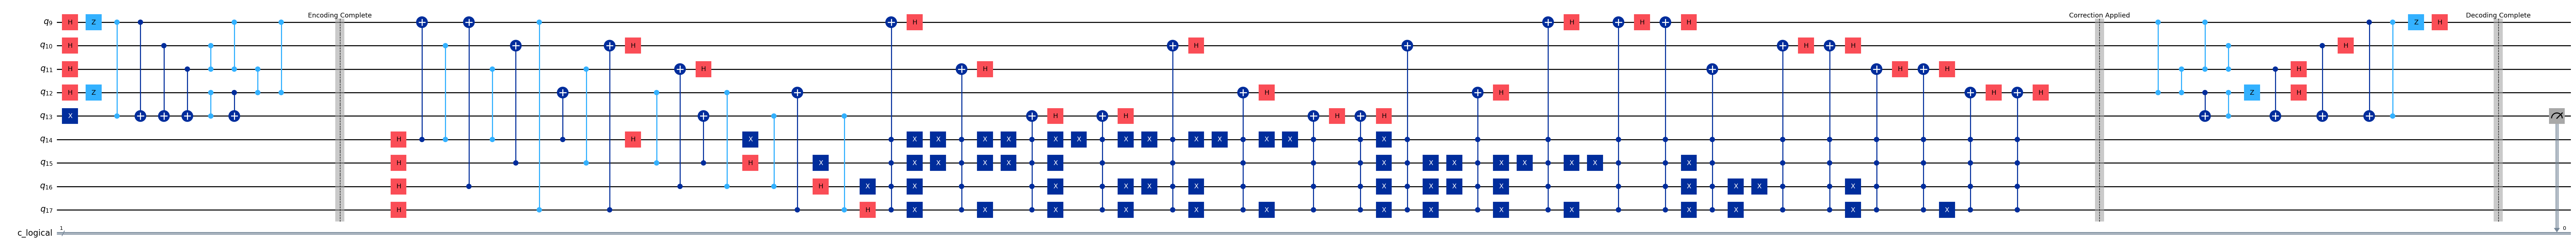

In [10]:
circuit_decoded.draw('mpl', fold=-1, idle_wires=False)

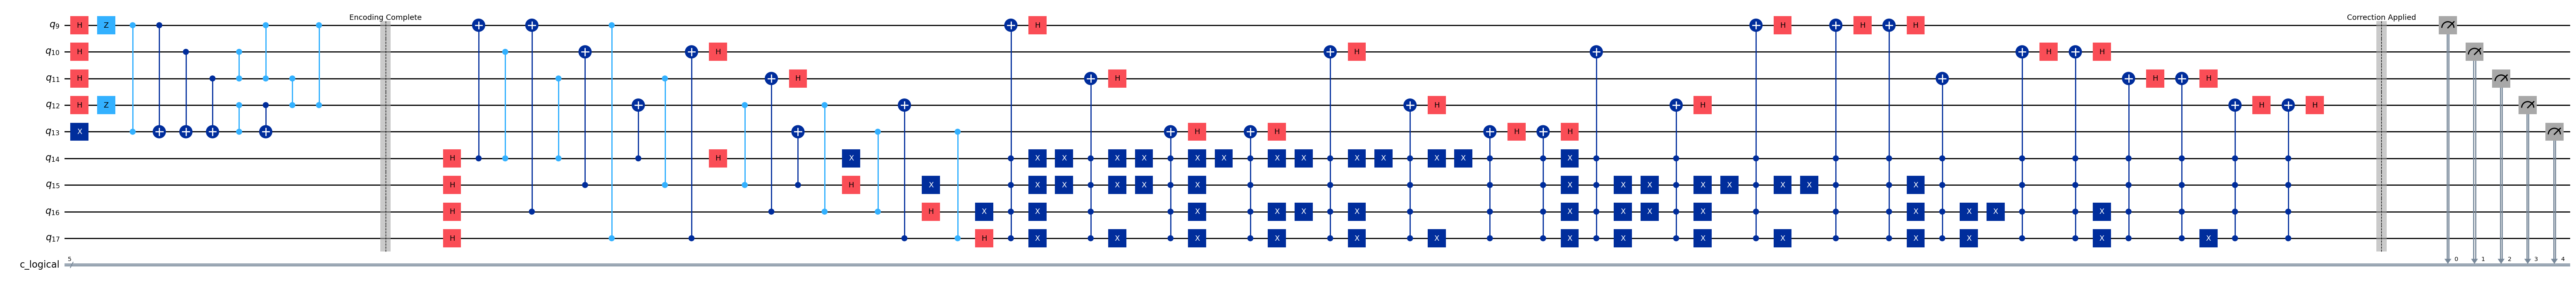

In [11]:
circuit_parity.draw('mpl', fold=-1, idle_wires=False)

In [12]:
# =============================================================================
# Test noiseless simulation of both circuit modes
# =============================================================================
# Transpile to basis gates only (no backend = no qubit count limit)
simulator = AerSimulator(noise_model=None, method='matrix_product_state')

# Test DECODED mode (1 classical bit)
decomposed_decoded = transpile(circuit_decoded, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
print(f"DECODED mode - Gate counts: {decomposed_decoded.count_ops()}")
result_decoded = simulator.run(decomposed_decoded, shots=NUM_SHOTS).result()
counts_decoded = dict(sorted(result_decoded.get_counts().items(), key=lambda x: x[0]))
print(f"  Counts: {counts_decoded}")

# Test PARITY mode (5 classical bits)
decomposed_parity = transpile(circuit_parity, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
print(f"\nPARITY mode - Gate counts: {decomposed_parity.count_ops()}")
result_parity = simulator.run(decomposed_parity, shots=NUM_SHOTS).result()
counts_parity = dict(sorted(result_parity.get_counts().items(), key=lambda x: x[0]))
print(f"  Counts: {counts_parity}")

# Verify logical outcome
success_decoded, _, _ = compute_logical_success_rate_decoded(counts_decoded, expected_logical_state='1')
success_parity, _, _ = compute_logical_success_rate_parity(counts_parity, expected_logical_state='1')
print(f"\nNoiseless success rates (expected |1⟩):")
print(f"  DECODED: {success_decoded:.4f}")
print(f"  PARITY:  {success_parity:.4f}")

DECODED mode - Gate counts: OrderedDict({'rz': 2440, 'sx': 988, 'cz': 396, 'x': 97, 'barrier': 3, 'measure': 1})
  Counts: {'1': 100}

PARITY mode - Gate counts: OrderedDict({'rz': 2414, 'sx': 976, 'cz': 386, 'x': 97, 'measure': 5, 'barrier': 2})
  Counts: {'00001': 8, '00010': 10, '00100': 6, '00111': 3, '01000': 9, '01011': 8, '01101': 4, '01110': 9, '10000': 4, '10011': 6, '10101': 5, '10110': 2, '11001': 6, '11010': 10, '11100': 4, '11111': 6}

Noiseless success rates (expected |1⟩):
  DECODED: 1.0000
  PARITY:  1.0000


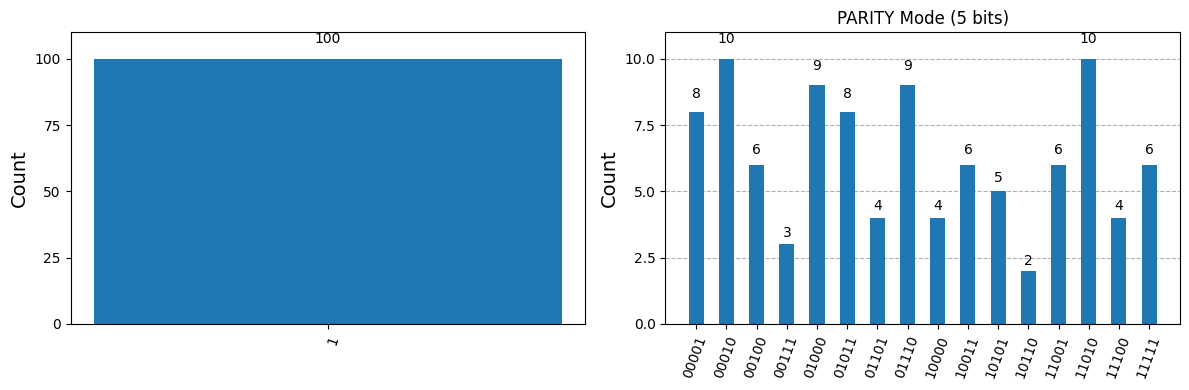

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_histogram(counts_decoded, ax=axes[0], title='DECODED Mode (1 bit)')
plot_histogram(counts_parity, ax=axes[1], title='PARITY Mode (5 bits)')
plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# NOISY SIMULATION (Proper Noise Application)
# =============================================================================
# CRITICAL: Transpile to FakeFez basis gates so noise model applies correctly!
# - basis_gates only (no backend) = no coupling map or qubit count constraints
# - SWAP → 3 CZ + 6 SX gates, all with noise defined

noisy_simulator = AerSimulator(
    noise_model=network_channel_noise,
    method='matrix_product_state'
)

# Transpile both circuits to basis gates for proper noise application
noisy_decoded = transpile(circuit_decoded, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
noisy_parity = transpile(circuit_parity, basis_gates=FEZ_BASIS_GATES, optimization_level=0)

print(f"DECODED circuit: {circuit_decoded.num_qubits} qubits, {circuit_decoded.num_clbits} classical bits")
print(f"  Gate counts: {noisy_decoded.count_ops()}")
print(f"\nPARITY circuit: {circuit_parity.num_qubits} qubits, {circuit_parity.num_clbits} classical bits")
print(f"  Gate counts: {noisy_parity.count_ops()}")
print(f"\nRunning with noise model from FakeFez ({fake_backend.num_qubits} qubits)")

DECODED circuit: 65 qubits, 1 classical bits
  Gate counts: OrderedDict({'rz': 2440, 'sx': 988, 'cz': 396, 'x': 97, 'barrier': 3, 'measure': 1})

PARITY circuit: 65 qubits, 5 classical bits
  Gate counts: OrderedDict({'rz': 2414, 'sx': 976, 'cz': 386, 'x': 97, 'measure': 5, 'barrier': 2})

Running with noise model from FakeFez (156 qubits)


In [15]:
noisy_decoded.draw('mpl', fold=-1, idle_wires=False)

In [16]:
noisy_parity.draw('mpl', fold=-1, idle_wires=False)

In [17]:
# Run noisy simulation on both circuits
print("Running noisy simulations...")
noisy_result_decoded = noisy_simulator.run(noisy_decoded, shots=NUM_SHOTS).result()
noisy_counts_decoded = dict(sorted(noisy_result_decoded.get_counts().items(), key=lambda x: x[0]))

noisy_result_parity = noisy_simulator.run(noisy_parity, shots=NUM_SHOTS).result()
noisy_counts_parity = dict(sorted(noisy_result_parity.get_counts().items(), key=lambda x: x[0]))

print(f"DECODED counts: {noisy_counts_decoded}")
print(f"PARITY counts (top 5): {dict(sorted(noisy_counts_parity.items(), key=lambda x: -x[1])[:5])}")

# Compute success rates
success_decoded, _, _ = compute_logical_success_rate_decoded(noisy_counts_decoded, expected_logical_state='1')
success_parity, _, _ = compute_logical_success_rate_parity(noisy_counts_parity, expected_logical_state='1')
print(f"\nNoisy success rates (expected |1⟩):")
print(f"  DECODED: {success_decoded:.4f}")
print(f"  PARITY:  {success_parity:.4f}")

Running noisy simulations...
DECODED counts: {'0': 13, '1': 87}
PARITY counts (top 5): {'00111': 9, '11001': 9, '11100': 8, '00010': 6, '00100': 6}

Noisy success rates (expected |1⟩):
  DECODED: 0.8700
  PARITY:  0.8400


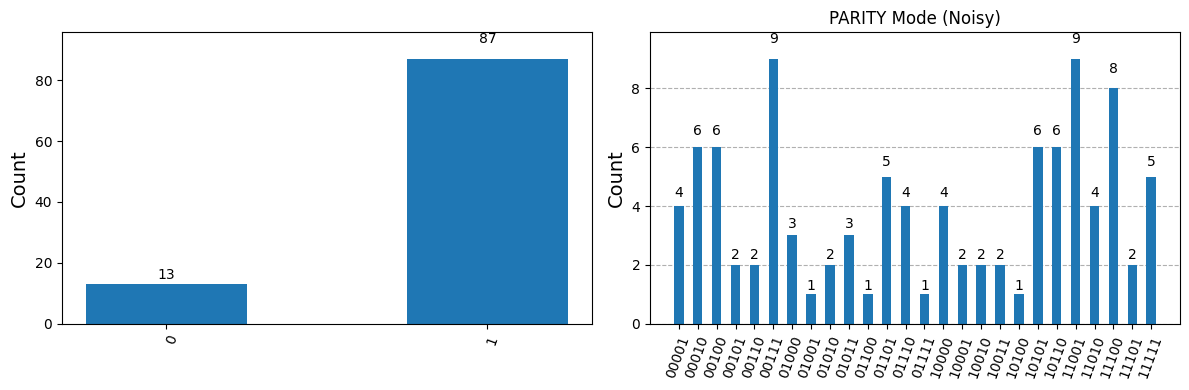

In [18]:
# Visualize noisy histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_histogram(noisy_counts_decoded, ax=axes[0], title='DECODED Mode (Noisy)')
plot_histogram(noisy_counts_parity, ax=axes[1], title='PARITY Mode (Noisy)')
plt.tight_layout()
plt.show()

In [20]:
# =============================================================================
# CLASSICAL CORRECTION IMPLEMENTATION
# =============================================================================
# Instead of coherent MCX gates (which explode into ~1200 basis gates),
# we measure the syndrome classically and apply conditional single-qubit gates.
#
# Pipeline:
#   Encode → Syndrome Measurement → Classical Conditional Correction → Transmit/Decode
#
# This is MUCH faster because:
#   - Only 15 single-qubit gates (one per syndrome) instead of 15 MCX gates
#   - c_if conditionals are handled efficiently by the simulator

def apply_classical_correction(qc, data_qubits, syndrome_register):
    """
    Apply error correction using classical conditionals (c_if).
    
    The syndrome has already been measured into syndrome_register.
    We apply conditional Pauli gates based on the measured syndrome value.
    
    Args:
        qc: QuantumCircuit to add corrections to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        syndrome_register: ClassicalRegister with 4 bits containing measured syndrome
    """
    from qiskit.circuit import IfElseOp
    from qiskit.circuit.library import XGate, ZGate
    
    for syndrome_val, correction in SYNDROME_TO_CORRECTION.items():
        if correction is None:
            continue
        
        qubit_idx, pauli = correction
        target = data_qubits[qubit_idx]
        
        # Apply the correction gate conditionally on syndrome value
        # Using the newer if_test syntax for Qiskit 1.x
        with qc.if_test((syndrome_register, syndrome_val)):
            if pauli == 'X':
                qc.x(target)
            elif pauli == 'Z':
                qc.z(target)
            elif pauli == 'Y':
                # Y = iXZ, but for correction we just need XZ (global phase doesn't matter)
                qc.x(target)
                qc.z(target)


def build_source_correcting_circuit_classical(node, initial_state='0', decode_before_measure=True):
    """
    Build a circuit with CLASSICAL error correction (fast version).
    
    Pipeline:
        1. Prepare data qubit
        2. Encode using [[5,1,3]] code
        3. Syndrome MEASUREMENT (collapses to classical bits)
        4. Classical conditional correction (single Pauli gates)
        5. Decode and measure OR measure 5 qubits
    
    Args:
        node: node ID (0-5)
        initial_state: '0' or '1'
        decode_before_measure: If True, decode then measure 1 qubit.
                               If False, measure 5 qubits (parity = logical outcome).
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    node_qubits = NODE_PHYSICAL_QUBITS[node]
    
    qc = QuantumCircuit(TOTAL_QUBITS)
    
    # Classical register for syndrome measurement
    syndrome_bits = ClassicalRegister(4, name='c_syndrome')
    qc.add_register(syndrome_bits)
    
    # Classical register for logical measurement
    if decode_before_measure:
        logical_bits = ClassicalRegister(1, name='c_logical')
    else:
        logical_bits = ClassicalRegister(5, name='c_logical')
    qc.add_register(logical_bits)
    
    # STEP 1: Prepare initial state
    if initial_state == '1':
        qc.x(node_qubits[4])

    # STEP 2: Encode using [[5,1,3]] code
    apply_encoding(qc, node_qubits[:5])
    qc.barrier(label='Encoding Complete')
    
    # STEP 3: Syndrome MEASUREMENT (not just extraction)
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
    for idx, stabilizer in enumerate(stabilizers):
        ancilla_idx = idx + 5
        qc.h(node_qubits[ancilla_idx])
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(node_qubits[ancilla_idx], node_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(node_qubits[ancilla_idx], node_qubits[qubit_idx])
        
        qc.h(node_qubits[ancilla_idx])
        qc.measure(node_qubits[ancilla_idx], syndrome_bits[idx])  # MEASURE!
    
    qc.barrier(label='Syndrome Measured')
    
    # STEP 4: Classical conditional correction (FAST!)
    data_qubits = [node_qubits[i] for i in range(5)]
    apply_classical_correction(qc, data_qubits, syndrome_bits)
    
    qc.barrier(label='Correction Applied')

    # STEP 5: Decode and measure
    if decode_before_measure:
        apply_decoding(qc, node_qubits[:5])
        qc.barrier(label='Decoding Complete')
        qc.measure(node_qubits[4], logical_bits[0])
    else:
        for i in range(5):
            qc.measure(node_qubits[i], logical_bits[i])

    return qc


# =============================================================================
# COMPARE: Coherent vs Classical Correction
# =============================================================================
print("=" * 70)
print("Comparing COHERENT vs CLASSICAL Correction")
print("=" * 70)

# Build coherent version (existing - slow)
circuit_coherent = build_source_correcting_circuit_physical(1, initial_state='1', decode_before_measure=True)
print(f"\nCOHERENT correction circuit:")
print(f"  Qubits: {circuit_coherent.num_qubits}, Classical bits: {circuit_coherent.num_clbits}")
print(f"  Gate counts: {circuit_coherent.count_ops()}")

# Build classical version (new - fast)
circuit_classical = build_source_correcting_circuit_classical(1, initial_state='1', decode_before_measure=True)
print(f"\nCLASSICAL correction circuit:")
print(f"  Qubits: {circuit_classical.num_qubits}, Classical bits: {circuit_classical.num_clbits}")
print(f"  Gate counts: {circuit_classical.count_ops()}")

# Transpile both and compare
print("\n" + "=" * 70)
print("After transpilation to basis gates:")
print("=" * 70)

decomposed_coherent = transpile(circuit_coherent, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
decomposed_classical = transpile(circuit_classical, basis_gates=FEZ_BASIS_GATES, optimization_level=0)

print(f"\nCOHERENT decomposed: {sum(decomposed_coherent.count_ops().values())} total gates")
print(f"  {decomposed_coherent.count_ops()}")

print(f"\nCLASSICAL decomposed: {sum(decomposed_classical.count_ops().values())} total gates")
print(f"  {decomposed_classical.count_ops()}")

Comparing COHERENT vs CLASSICAL Correction

COHERENT correction circuit:
  Qubits: 65, Classical bits: 1
  Gate counts: OrderedDict({'x': 57, 'h': 36, 'cz': 20, 'mcx': 20, 'cx': 16, 'z': 4, 'barrier': 3, 'measure': 1})

CLASSICAL correction circuit:
  Qubits: 65, Classical bits: 5
  Gate counts: OrderedDict({'cz': 20, 'h': 16, 'cx': 16, 'if_else': 15, 'measure': 5, 'z': 4, 'barrier': 4, 'x': 1})

After transpilation to basis gates:

COHERENT decomposed: 3925 total gates
  OrderedDict({'rz': 2440, 'sx': 988, 'cz': 396, 'x': 97, 'barrier': 3, 'measure': 1})

CLASSICAL decomposed: 209 total gates
  OrderedDict({'rz': 100, 'sx': 48, 'cz': 36, 'if_else': 15, 'measure': 5, 'barrier': 4, 'x': 1})


In [21]:
# =============================================================================
# TIMING COMPARISON: Coherent vs Classical
# =============================================================================
import time

print("=" * 70)
print("Simulation Timing Comparison")
print("=" * 70)

# Run classical version (should be fast)
print("\nRunning CLASSICAL correction simulation...")
start_time = time.time()
result_classical = noisy_simulator.run(decomposed_classical, shots=NUM_SHOTS).result()
classical_time = time.time() - start_time
counts_classical = result_classical.get_counts()
print(f"  Time: {classical_time:.2f} seconds")
print(f"  Counts: {counts_classical}")

# Compute success rate
# Note: Classical correction has 2 registers, need to parse correctly
# Format is "logical syndrome" - we want the logical part
success_classical = 0
total_classical = 0
for bitstring, count in counts_classical.items():
    total_classical += count
    # The logical bit is the leftmost part (before space)
    parts = bitstring.split()
    if len(parts) == 2:
        logical_bit = parts[0]
    else:
        logical_bit = bitstring
    if logical_bit == '1':  # We prepared |1⟩
        success_classical += count

print(f"  Success rate: {success_classical/total_classical:.4f}")

# Run coherent version (will be slow!)
print("\nRunning COHERENT correction simulation (this may take a while)...")
start_time = time.time()
result_coherent = noisy_simulator.run(decomposed_coherent, shots=NUM_SHOTS).result()
coherent_time = time.time() - start_time
counts_coherent = result_coherent.get_counts()
print(f"  Time: {coherent_time:.2f} seconds")
print(f"  Counts: {counts_coherent}")

# Compute success rate for coherent
success_coherent = counts_coherent.get('1', 0)
total_coherent = sum(counts_coherent.values())
print(f"  Success rate: {success_coherent/total_coherent:.4f}")

# Summary
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Classical correction: {classical_time:.2f}s | Success: {success_classical/total_classical:.4f}")
print(f"Coherent correction:  {coherent_time:.2f}s | Success: {success_coherent/total_coherent:.4f}")
print(f"Speedup: {coherent_time/classical_time:.1f}x faster with classical correction")

Simulation Timing Comparison

Running CLASSICAL correction simulation...
  Time: 1.01 seconds
  Counts: {'0 0001': 1, '1 0100': 1, '1 1111': 1, '1 0000': 94, '0 0000': 1, '1 0010': 2}
  Success rate: 0.9800

Running COHERENT correction simulation (this may take a while)...
  Time: 17.82 seconds
  Counts: {'0': 10, '1': 90}
  Success rate: 0.9000

SUMMARY
Classical correction: 1.01s | Success: 0.9800
Coherent correction:  17.82s | Success: 0.9000
Speedup: 17.6x faster with classical correction
